# Imports

In [61]:
import numpy as np
import zarr
import napari

import requests

import os
# Ensure tensorstore does not attempt to use GCE credentials
os.environ['GCE_METADATA_ROOT'] = 'metadata.google.internal.invalid'
import tensorstore as ts
import matplotlib.pyplot as plt

# Load the data

[<img src="assets/H01_dataset_landing_page.png" width="800">](https://h01-release.storage.googleapis.com/data.html)

The H01 dataset includes a wealth of data, over 50,000 cells and 130 million synaptic connections. The 3D world of the brain is browsable in [Neuroglancer](https://h01-dot-neuroglancer-demo.appspot.com/#!gs://h01-release/assets/library_state.json), all included, from large neurons down to single synapses. Below is an overview of some of the cell types and structures available. Click on the links and explore examples in Neuroglancer.

In [63]:
context = ts.Context({'cache_pool': {'total_bytes_limit': 1000000000}})

In [64]:
url = "https://storage.googleapis.com/h01-release/data/20210601/4nm_raw/info"
info = requests.get(url).json()

print("Available precomputed resolutions:")
for i, scale in enumerate(info["scales"]):
    print(f"Index {i}: {scale['resolution']}")

Available precomputed resolutions:
Index 0: [4, 4, 33]
Index 1: [8, 8, 33]
Index 2: [16, 16, 33]
Index 3: [32, 32, 33]
Index 4: [64, 64, 66]
Index 5: [128, 128, 132]
Index 6: [256, 256, 264]
Index 7: [512, 512, 528]
Index 8: [1024, 1024, 1056]
Index 9: [2048, 2048, 2112]
Index 10: [4096, 4096, 4224]
Index 11: [8192, 8192, 8448]
Index 12: [16384, 16384, 16896]


In [65]:
target_resolution = info["scales"][9]["resolution"]
target_resolution

[2048, 2048, 2112]

In [66]:
em_8nm = ts.open({
    'driver': 'neuroglancer_precomputed',
    'kvstore': {'driver': 'gcs', 'bucket': 'h01-release'},
    'path': 'data/20210601/4nm_raw',
    'scale_metadata': {'resolution': target_resolution}},
    read=True, context=context).result()[ts.d['channel'][0]]
c3_segmentation_8nm = ts.open({
    'driver': 'neuroglancer_precomputed',
    'kvstore': {'driver': 'gcs', 'bucket': 'h01-release'},
    'path': 'data/20210601/c3',
    'scale_metadata': {'resolution': target_resolution}},
    read=True, context=context).result()[ts.d['channel'][0]]
c3_segmentation_8nm_subcompartments = ts.open({
    'driver': 'neuroglancer_precomputed',
    'kvstore': {'driver': 'gcs', 'bucket': 'h01-release'},
    'path': 'data/20210601/c3/subcompartments',
    'scale_metadata': {'resolution': target_resolution}},
    read=True, context=context).result()[ts.d['channel'][0]]

In [67]:
em_8nm.shape, c3_segmentation_8nm.shape, c3_segmentation_8nm_subcompartments.shape

((2016, 1393, 83), (2016, 1393, 83), (2016, 1393, 83))

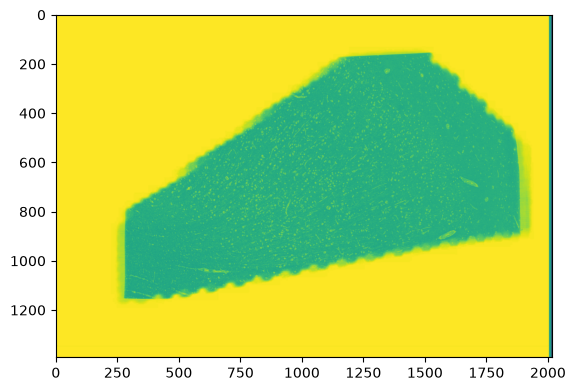

In [68]:
plt.imshow(em_8nm[:, :, 10].transpose())

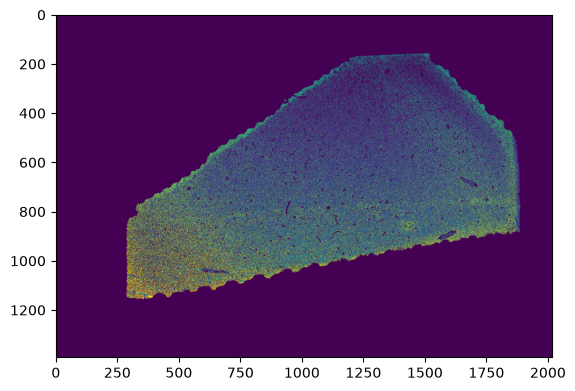

In [69]:
plt.imshow(c3_segmentation_8nm[:, :, 10].transpose())

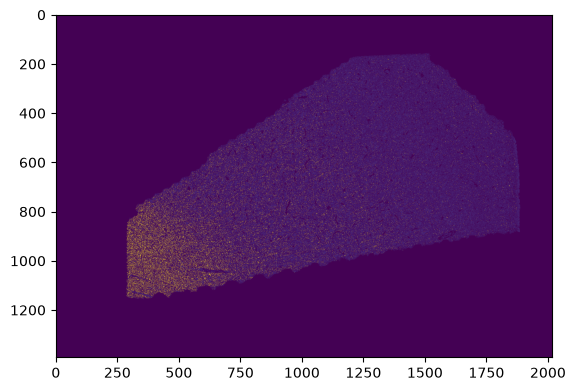

In [70]:
plt.imshow(c3_segmentation_8nm_subcompartments[..., 10].transpose())

In [12]:
# np.unique(c3_segmentation_8nm_subcompartments)

array([   0,   99,  100,  101,  102,  103,  104,  105, 1100, 1101, 1102,
       1103], dtype=uint64)

In [71]:
em_8nm.shape

(2016, 1393, 83)

In [13]:
em_8nm_transposed = em_8nm.transpose()
c3_segmentation_8nm_transposed = c3_segmentation_8nm.transpose()
c3_segmentation_8nm_subcompartments_transposed = c3_segmentation_8nm_subcompartments.transpose()

In [14]:
# 100=Axon, 101=Dendrite, 102=Soma, 104=AIS
# We also include the 1100-series assuming they are dendritic spines/synaptic structures
# neuronal_classes = [100, 101, 102, 104, 1100, 1101, 1102, 1103]
# neuronal_classes = [101, 102, 103]
neuronal_classes = [103] # dendrite only

In [15]:
# Define your volume bounds
z_slice, y_slice, x_slice = slice(0, 70), slice(979-300, 979), slice(737-150, 737+150)

# 1. Read the instance IDs (the noisy, colorful array)
c3_instances = c3_segmentation_8nm_transposed[z_slice, y_slice, x_slice].read().result()

# 2. Read the semantic classes (the 1-6 categories) for the EXACT same volume
c3_semantics = c3_segmentation_8nm_subcompartments_transposed[z_slice, y_slice, x_slice].read().result()

em_orig = em_8nm_transposed[z_slice, y_slice, x_slice].read().result()

# 3. Create a boolean mask of ONLY neuronal structures
# 1=Axon, 2=Dendrite, 3=Soma, 5=Axon Initial Segment (excluding 4=Astrocyte/Glia, 6=Cilia, 0=Background)
neuronal_mask = np.isin(c3_semantics, neuronal_classes)

# 4. Apply the mask
# Keep the unique instance ID where the mask is True, otherwise set to 0
clean_neurons_only = np.where(neuronal_mask, c3_instances, 0)

In [16]:
np.unique(clean_neurons_only)

array([          0,  2976327260,  3091704283, ..., 86779029210,
       86781103769, 86794870945], shape=(11308,), dtype=uint64)

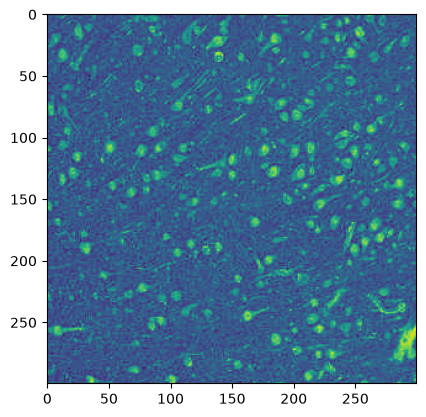

In [17]:
plt.imshow(em_orig[2, ...])

In [18]:
clean_neurons_only.shape

(70, 300, 300)

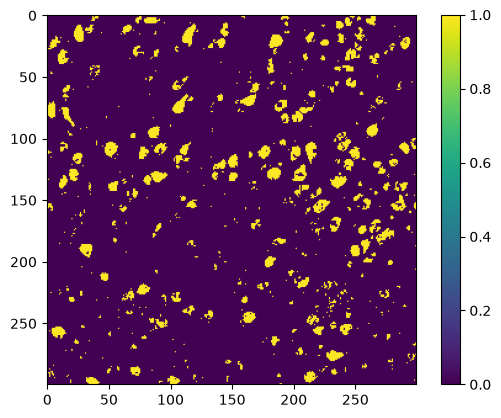

In [19]:
plt.imshow(c3_semantics[2, ...] == 103)
plt.colorbar()

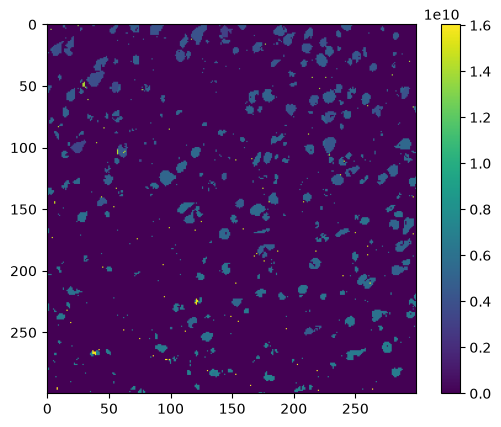

In [20]:
plt.imshow(clean_neurons_only[10, ...])
plt.colorbar()

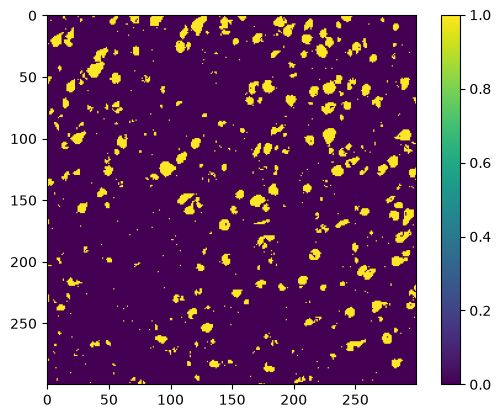

In [21]:
plt.imshow(neuronal_mask[10, ...])
plt.colorbar()

In [27]:
em_8nm_transposed.shape

(83, 1393, 2016)

In [76]:
clean_neurons_only.shape

(70, 300, 300)

In [77]:
viewer = napari.Viewer(ndisplay=3)

viewer.add_image(
    em_orig,
    name="EM",
    scale=(2048, 2048, 2112), # Maps to the (Z, X, Y) axes
    rendering="mip"
)
)
viewer.add_labels(clean_neurons_only, scale=(2048, 2048, 2112), name="neurons_axons_soma_annotation")

napari.run()

# Segment from scratch with CellPose

In [78]:
from cellpose import models

In [79]:
model = models.CellposeModel(
    gpu=True, model_type='cyto3'
)

In [80]:
diameter = 10

In [81]:
em_orig.shape

(70, 300, 300)

In [82]:
masks, flows, styles = model.eval(
    em_orig,
    z_axis=0,
    do_3D=True, 
)

/home/sysbio/miniforge3/envs/CRABS_2026_connectomics/lib/python3.12/site-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


In [83]:
masks.shape

(70, 300, 300)

In [84]:
viewer = napari.Viewer(ndisplay=3)

viewer.add_image(
    em_orig,
    name="EM",
    scale=(2048, 2048, 2112), # scale=(2112, 2048, 2048),# scale=(128, 128, 33),  # Maps to the (Z, X, Y) axes
    rendering="mip"
)

viewer.add_labels(clean_neurons_only, scale=(2048, 2048, 2112), name="neurons_axons_soma_annotation")
viewer.add_labels(masks, scale=(2048, 2048, 2112), name="cellpose_segmentation")

napari.run()

# Connectivity analysis (isn't really informative :))

In [110]:
import pandas as pd
from skimage.measure import regionprops
from skimage.measure import regionprops_table
from scipy import ndimage
import networkx as nx

In [94]:
# =====================================================================
# BIOLOGICAL INFERENCE 1: MORPHOLOGICAL PROFILING
# =====================================================================
print("--> Step 2: Running Biological Inference - Cell Morphology...")
# Convert Zarr to numpy slice or handle chunk-by-chunk if dataset is massive
seg_np = masks[:]

--> Step 2: Running Biological Inference - Cell Morphology...


In [95]:
# Extract biological shape features for cell typing
properties = ['label', 'area', 'major_axis_length', 'minor_axis_length']
morph_df = pd.DataFrame(regionprops_table(seg_np, properties=properties))
morph_df.rename(columns={'area': 'volume_voxels'}, inplace=True)

In [97]:
morph_df['volume_voxels'].mean()

np.float64(427.2523939808481)

In [102]:
# Infer cell sub-types based on structural rules (Example Logic)
morph_df['Inferred_Type'] = np.where(morph_df['volume_voxels'] > 600, 'Pyramidal Neuron', 'Interneuron')
morph_df.head(10)

,label,volume_voxels,major_axis_length,minor_axis_length,Inferred_Type
0,1,312.0,9.448798,7.967062,Interneuron
1,2,28.0,6.612419,2.236068,Interneuron
2,3,92.0,12.047698,3.299115,Interneuron
3,4,122.0,7.579483,5.320240,Interneuron
4,5,562.0,15.577215,8.490457,Interneuron
5,6,128.0,8.219250,4.342697,Interneuron
6,7,66.0,5.902643,4.557574,Interneuron
7,8,128.0,8.237949,5.054902,Interneuron
8,9,702.0,22.240596,8.916370,Pyramidal Neuron
9,10,533.0,11.567318,9.117308,Interneuron


In [113]:
# =====================================================================
# BIOLOGICAL INFERENCE 2: STRUCTURAL CONNECTOME INFERENCE
# =====================================================================
print("--> Step 3: Running Biological Inference - Synaptic Contact Mapping...")
# Dilate cell boundaries slightly to find adjacent touching membranes
struct_element = ndimage.generate_binary_structure(3, 1) # 6-connectivity
dilated = ndimage.binary_dilation(seg_np, structure=struct_element)

# Find edges where different cell IDs overlap due to dilation
boundary_mask = (dilated != seg_np) & (seg_np > 0) & (dilated > 0)

# Build physical connection weight arrays
source_neurons = seg_np[boundary_mask]
target_neurons = dilated[boundary_mask]

# Create a structural adjacency dataframe
edges_df = pd.DataFrame({'Source': source_neurons, 'Target': target_neurons})
# Count voxel contact area as proxy for synaptic weight
weights_df = edges_df.groupby(['Source', 'Target']).size().reset_index(name='Contact_Area')
# Clean up self-loops and duplicates
weights_df = weights_df[weights_df['Source'] < weights_df['Target']]
print("\nInferred Synaptic Contact Interfaces:")
print(weights_df.to_string(index=False))

--> Step 3: Running Biological Inference - Synaptic Contact Mapping...

Inferred Synaptic Contact Interfaces:
Empty DataFrame
Columns: [Source, Target, Contact_Area]
Index: []


In [ ]:
# =====================================================================
# BIOLOGICAL INFERENCE 3: TOPOLOGICAL NETWORK ANALYSIS
# =====================================================================
print("\n--> Step 4: Running Biological Inference - Circuit Topology...")
G = nx.Graph()

# Add biological metadata to graph nodes
for _, row in morph_df.iterrows():
    G.add_node(int(row['label']), type=row['Inferred_Type'], size=row['volume_voxels'])

# Add structural edges scaled by contact area
for _, row in weights_df.iterrows():
    G.add_edge(int(row['Source']), int(row['Target']), weight=int(row['Contact_Area']))

# Infer critical network hubs via Centrality Metrics
centrality = nx.degree_centrality(G)
nx.set_node_attributes(G, centrality, 'centrality')

for node, data in G.nodes(data=True):
    print(f" Neuron {node} ({data['type']}): Circuit Centrality = {data['centrality']:.2f}")

# =====================================================================
# VISUALIZATION OF INFERRED CIRCUIT
# =====================================================================
fig, ax = plt.subplots(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)

# Color code by biological inferred type
colors = ['orange' if G.nodes[n]['type'] == 'Pyramidal Neuron' else 'lightgreen' for n in G.nodes]
widths = [G[u][v]['weight'] / 100 for u, v in G.edges()] # Scale lines by contact area

nx.draw(G, pos, with_labels=True, node_color=colors, node_size=1000, 
        width=widths, edge_color='gray', font_weight='bold', ax=ax)
plt.title("Inferred Functional Circuit Architecture")
plt.show()

# Sholl analysis

## Helper functions

In [124]:
import numpy as np
import pandas as pd
from skimage.measure import regionprops
from scipy.spatial import KDTree
import tqdm
from skimage.morphology import skeletonize
from scipy.ndimage import distance_transform_edt
from skimage import measure


def keep_top_n_3d_masks(masks, top_n=5):
    # Get properties of all labeled regions
    props = regionprops(masks)
    if not props:
        return np.zeros_like(masks)
    
    # Sort regions by volume (area) in descending order
    props_sorted = sorted(props, key=lambda r: r.area, reverse=True)
    
    # Keep only the top N labels
    top_labels = [p.label for p in props_sorted[:top_n]]
    
    # Create a new mask array keeping only selected labels
    filtered_masks = np.where(np.isin(masks, top_labels), masks, 0)
    
    # Relabel sequentially to keep clean indices (optional)
    from skimage.segmentation import relabel_sequential
    filtered_masks, _, _ = relabel_sequential(filtered_masks)
    
    return filtered_masks, np.array(top_labels)

# Example usage assuming 'masks' is your 3D Cellpose output array:
# top_masks = keep_top_n_3d_masks(masks, top_n=10)


def extract_neuron_metrics(masks, sample_id, group_name, voxel_size=[1.5, 0.3, 0.3]):
    """
    Extracts 3D metrics and scales them to physical units (microns).
    voxel_size format: [Z_spacing, Y_spacing, X_spacing] in micrometers.
    """
    # Compute the physical volume of a single voxel
    voxel_volume_um3 = np.prod(voxel_size)
    
    props = regionprops(masks)
    cell_data = []
    
    for p in tqdm.tqdm(props):
        # Skip tiny artifacts/noise
        if p.area < 10:
            continue
            
        # Calculate real-world metrics
        volume_um3 = p.area * voxel_volume_um3
        
        # Scale centroids to physical space (Z, Y, X)
        centroid_um = [c * v for c, v in zip(p.centroid, voxel_size)]
        
        # Spherical cap approximation / principal axis length scaled to Z
        major_axis_um = p.major_axis_length * voxel_size[1] # Using XY pixel spacing
        
        cell_data.append({
            "sample_id": sample_id,
            "group": group_name,
            "cell_id": p.label,
            "volume_um3": volume_um3,
            "solidity": p.solidity, # Density metric (1.0 means perfectly solid)
            "major_axis_um": major_axis_um,
            "pos_z_um": centroid_um[0],
            "pos_y_um": centroid_um[1],
            "pos_x_um": centroid_um[2]
        })
        
    return pd.DataFrame(cell_data)

# # --- Mock Execution for the Example ---
# # In a real study, you would loop over your image files and collect dataframes
# # Let's generate synthetic data to simulate a 3-subject study per group:
# df_control = pd.concat([extract_neuron_metrics((np.random.rand(50,256,256) > 0.995).astype(int), f"Ctrl_{i}", "Control") for i in range(3)])
# df_stressed = pd.concat([extract_neuron_metrics((np.random.rand(50,256,256) > 0.996).astype(int), f"Str_{i}", "Stressed") for i in range(3)])

# # Combine into a single master database
# df_master = pd.concat([df_control, df_stressed], ignore_index=True)


def calculate_nearest_neighbors(df):
    """Calculates Nearest Neighbor Distance (NND) for each cell within its sample."""
    df_out = df.copy()
    df_out['nnd_um'] = np.nan
    
    # Process each tissue sample independently
    for sample in df_out['sample_id'].unique():
        sample_mask = df_out['sample_id'] == sample
        sample_cells = df_out[sample_mask]
        
        if len(sample_cells) < 2:
            continue
            
        # Extract 3D physical coordinates
        coords = sample_cells[['pos_z_um', 'pos_y_um', 'pos_x_um']].values
        
        # Build spatial look-up tree
        tree = KDTree(coords)
        
        # Query the 2 closest points (the 1st point is always the cell itself, distance=0)
        distances, _ = tree.query(coords, k=2)
        
        # Store the distance to the 2nd closest point (the actual nearest neighbor)
        df_out.loc[sample_mask, 'nnd_um'] = distances[:, 1]
        
    return df_out


# df_master = calculate_nearest_neighbors(df_master)


def compute_3d_sholl_profile(binary_mask, centroid, voxel_size=[1.5, 0.3, 0.3], step_size_um=2.0, max_radius_um=50.0):
    """
    Computes a 3D Sholl intersection profile for an individual skeletonized cell mask.
    Returns radii arrays and corresponding intersection counts.
    """
    # 1. Thin out the cell into a 1-pixel wide 3D skeleton backbone
    skeleton = skeletonize(binary_mask).astype(bool)
    if np.sum(skeleton) == 0:
        return np.array([]), np.array([])
        
    # 2. Build a coordinate grid matching the physical micron dimensions
    z, y, x = np.indices(binary_mask.shape)
    z_phys = (z - centroid[0]) * voxel_size[0]
    y_phys = (y - centroid[1]) * voxel_size[1]
    x_phys = (x - centroid[2]) * voxel_size[2]
    
    # Calculate the 3D Euclidean distance of every single voxel from the soma center
    distance_map = np.sqrt(z_phys**2 + y_phys**2 + x_phys**2)
    
    # Isolate distance measurements only along the structural skeleton path
    skeleton_distances = distance_map[skeleton]
    
    # 3. Sample intersections at concentric radial steps
    radii = np.arange(step_size_um, max_radius_um + step_size_um, step_size_um)
    intersections = []
    
    for r in radii:
        # Count how many skeletal branches pass right through this radial shell boundary
        # A branch crosses if its distance falls tightly within a 1-micron shell tolerance window
        crossings = np.sum((skeleton_distances >= r - 0.5) & (skeleton_distances <= r + 0.5))
        intersections.append(crossings)
        
    return radii, np.array(intersections)

def batch_sholl_analysis(masks, group_name, sample_id, voxel_size=[1.5, 0.3, 0.3]):
    """Loops through all cells in a mask stack and extracts unified Sholl profiles."""
    props = regionprops(masks)
    all_profiles = []
    
    for p in tqdm.tqdm(props):
        if p.area < 50:  # Ignore fragments; Sholl requires actual branch volumes
            continue
            
        # Isolate individual cell boundary
        cell_mask = (masks == p.label)
        
        # Compute Sholl curves
        radii, intersections = compute_3d_sholl_profile(cell_mask, p.centroid, voxel_size)
        
        if len(intersections) == 0:
            continue
            
        # Extract summary scalar metrics derived from the Sholl Curve
        peak_intersections = np.max(intersections)  # Max branching density
        critical_radius = radii[np.argmax(intersections)]  # Distance where branching peaks
        sholl_auc = np.trapezoid(intersections, x=radii)  # Total arborization complexity index
        
        all_profiles.append({
            "sample_id": sample_id,
            "group": group_name,
            "cell_id": p.label,
            "peak_intersections": peak_intersections,
            "critical_radius_um": critical_radius,
            "sholl_complexity_auc": sholl_auc,
            "radii": radii,
            "intersections": intersections
        })
        
    return all_profiles




In [133]:
largest_neurons, top_labels = keep_top_n_3d_masks(masks, top_n=20)

In [144]:
top_labels

array([ 163, 1234,  563, 1227,  438,  821,  963,  159,  267,  877,  282,
         32,   31,  874,   26,  979,  300, 1072,  360,  294])

In [135]:
largest_neuron_labels = np.unique(largest_neurons)[1:]  # Skip background (0)


# Initialize empty master lists to collect mesh data
all_verts = []
all_faces = []
all_values = []
vertex_count_offset = 0

# Loop and extract data from each cell
for label_id in tqdm.tqdm(largest_neuron_labels):
    binary_cell = (largest_neurons == label_id)
    if np.sum(binary_cell) < 10:
        continue
        
    # Generate vertices and faces for current cell
    verts, faces, _, _ = measure.marching_cubes(binary_cell.astype(float), level=0.5)
    
    # Track the mesh offset so the faces map to the correct global vertices
    global_faces = faces + vertex_count_offset
    vertex_count_offset += len(verts)
    
    # Assign a single ID number to all vertices belonging to this cell
    # Napari will use this ID array to apply distinct colors across the colormap
    vertex_values = np.ones(len(verts)) * label_id
    
    # Append to master lists
    all_verts.append(verts)
    all_faces.append(global_faces)
    all_values.append(vertex_values)

# Vertically stack everything into unified 2D numpy arrays
master_verts = np.vstack(all_verts)
master_faces = np.vstack(all_faces)
master_values = np.concatenate(all_values)

# Combine into the official Napari surface tuple format
# (vertices, faces, vertex_values)
combined_surface_data = (master_verts, master_faces, master_values)

100%|█████████████████████████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 14.77it/s]


In [138]:
target_resolution

[2048, 2048, 2112]

In [141]:
# Initialize Napari viewer
viewer = napari.Viewer(ndisplay=3)

voxel_scale = target_resolution

viewer.add_image(
    em_orig,
    name="EM",
    rendering="mip", 
    scale=voxel_scale
)

viewer.add_labels(
    masks,
    name="CellPose_segmentation",
    scale=voxel_scale
)


# Add all neurons combined into a single surface layer
viewer.add_surface(
    combined_surface_data, 
    name='All Largest Neurons Meshes', 
    opacity=0.6,
    colormap='turbo',  # 'turbo' gives excellent distinct colors for labels
    contrast_limits=[min(largest_neuron_labels), max(largest_neuron_labels)], 
    scale=voxel_scale
)

napari.run()

In [143]:
sholl_profiles = batch_sholl_analysis(largest_neurons, "CellPose", "H01")

100%|█████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  5.35it/s]


In [146]:
c3_instances.shape

(70, 300, 300)

In [147]:
largest_neurons.shape

(70, 300, 300)

In [154]:
np.unique(c3_instances)

array([          0,  1885968871,  2103144214, ..., 86795645356,
       86795674809, 86795732646], shape=(2401052,), dtype=uint64)

In [155]:
top_labels

array([ 163, 1234,  563, 1227,  438,  821,  963,  159,  267,  877,  282,
         32,   31,  874,   26,  979,  300, 1072,  360,  294])

In [162]:
mask = np.isin(c3_instances, np.unique(c3_instances)[:20]) # this is just as an example, because cellpose indices differ from these labels
c3_instances_top_labels = np.where(mask, c3_instances, 0)

In [163]:
c3_instances_top_labels.shape

(70, 300, 300)

In [164]:
np.unique(c3_instances_top_labels)

array([         0, 1885968871, 2103144214, 2233355303, 2236085365,
       2262382003, 2276967555, 2494640672, 2584392112, 2656316309,
       2700163501, 2771124717, 2771884890, 2800721720, 2801844771,
       2815862747, 2872995228, 2887610997, 2902519508, 2903920410],
      dtype=uint64)

In [165]:
# Relabel sequentially to keep clean indices (optional)
from skimage.segmentation import relabel_sequential
c3_instances_top_labels_seq, _, _ = relabel_sequential(c3_instances_top_labels)

In [166]:
sholl_profiles_precomputed = batch_sholl_analysis(c3_instances_top_labels_seq, "PrecomputedSegmentation", "H01")

100%|████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 124.86it/s]


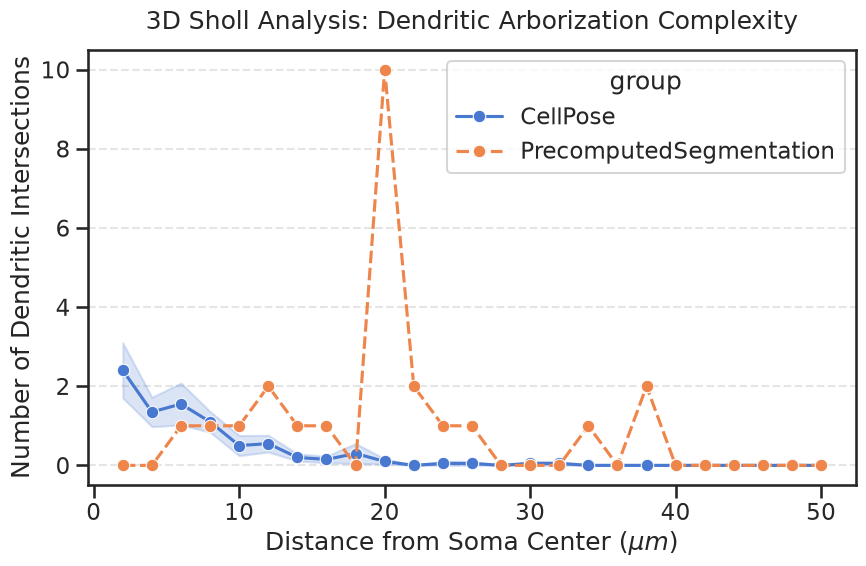

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

# Explode the profile list to create an aggregate line plot format
records = []
for p in sholl_profiles + sholl_profiles_precomputed:
    for r, count in zip(p['radii'], p['intersections']):
        records.append({
            "group": p['group'],
            "sample_id": p['sample_id'],
            "cell_id": p['cell_id'],
            "radius_um": r,
            "intersections": count
        })
df_curves = pd.DataFrame(records)

# Plotting the population-wide Sholl Profile
plt.figure(figsize=(9, 6))
sns.set_theme(style="ticks", context="talk")

sns.lineplot(
    data=df_curves, 
    x="radius_um", 
    y="intersections", 
    hue="group", 
    style="group",
    marker="o", 
    errorbar="se", # Displays Standard Error of the Mean (SEM) shading
    palette="muted"
)

plt.title("3D Sholl Analysis: Dendritic Arborization Complexity", pad=15)
plt.xlabel(r"Distance from Soma Center ($\mu m$)")
plt.ylabel("Number of Dendritic Intersections")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [169]:
# Initialize Napari viewer
viewer = napari.Viewer(ndisplay=3)

voxel_scale = target_resolution

viewer.add_image(
    em_orig,
    name="EM",
    rendering="mip", 
    scale=voxel_scale
)

viewer.add_labels(
    masks,
    name="CellPose_segmentation",
    scale=voxel_scale
)

viewer.add_labels(
    c3_instances_top_labels_seq,
    name="Precomputed_segmentation_20_neurons",
    scale=voxel_scale
)

# Add all neurons combined into a single surface layer
viewer.add_surface(
    combined_surface_data, 
    name='Top 20 Largest Neurons Meshes', 
    opacity=0.6,
    colormap='turbo',  # 'turbo' gives excellent distinct colors for labels
    contrast_limits=[min(largest_neuron_labels), max(largest_neuron_labels)], 
    scale=voxel_scale
)

napari.run()

In [170]:
# TODO: run cellpose with different diameter and compare Sholl profiles 

# More datasets

In [171]:
import zarr

In [172]:
zarr_group = zarr.open(
    "s3://idr/zarr/v0.4/idr0048A/9846152.zarr/",
    storage_options={
        "anon": True,
        "client_kwargs": {
            "endpoint_url": "https://livingobjects.ebi.ac.uk"
        }
    }
)

# store = zarr.open("https://data-humerus.webknossos.org/data/zarr3_experimental/678f991f01000028077f4462/image", mode="r")
# store = zarr.open("https://livingobjects.ebi.ac.uk/idr/zarr/v0.4/idr0048A/9846152.zarr/", mode="r")

In [173]:
zarr_group.tree()

/home/sysbio/miniforge3/envs/CRABS_2026_connectomics/lib/python3.12/site-packages/zarr/core/group.py:3409: ZarrUserWarning: Object at METADATA.ome.xml is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


/
├── 0 (3, 91, 13350, 19120) uint16
├── 1 (3, 91, 6675, 9560) uint16
├── 2 (3, 91, 3337, 4780) uint16
├── 3 (3, 91, 1668, 2390) uint16
├── 4 (3, 91, 834, 1195) uint16
├── 5 (3, 91, 417, 597) uint16
├── 6 (3, 91, 208, 298) uint16
├── 7 (3, 91, 104, 149) uint16
├── 8 (3, 91, 52, 74) uint16
└── OME

In [174]:
print(zarr_group.metadata)

GroupMetadata(attributes={'_creator': {'name': 'omero-zarr', 'version': '0.5.2.dev20+g6af4061'}, 'multiscales': [{'axes': [{'name': 'c', 'type': 'channel'}, {'name': 'z', 'type': 'space'}, {'name': 'y', 'type': 'space'}, {'name': 'x', 'type': 'space'}], 'datasets': [{'coordinateTransformations': [{'scale': [1.0, 1.0, 1.0, 1.0], 'type': 'scale'}], 'path': '0'}, {'coordinateTransformations': [{'scale': [1.0, 1.0, 2.0, 2.0], 'type': 'scale'}], 'path': '1'}, {'coordinateTransformations': [{'scale': [1.0, 1.0, 4.0, 4.0], 'type': 'scale'}], 'path': '2'}, {'coordinateTransformations': [{'scale': [1.0, 1.0, 8.0, 8.0], 'type': 'scale'}], 'path': '3'}, {'coordinateTransformations': [{'scale': [1.0, 1.0, 16.0, 16.0], 'type': 'scale'}], 'path': '4'}, {'coordinateTransformations': [{'scale': [1.0, 1.0, 32.0, 32.0], 'type': 'scale'}], 'path': '5'}, {'coordinateTransformations': [{'scale': [1.0, 1.0, 64.0, 64.0], 'type': 'scale'}], 'path': '6'}, {'coordinateTransformations': [{'scale': [1.0, 1.0, 128

In [175]:
print(zarr_group.info)

Name        : 
Type        : Group
Zarr format : 2
Read-only   : False
Store type  : FsspecStore


In [176]:
zarr_group['8'].chunks

(1, 1, 52, 74)

In [177]:
zarr_group.attrs['multiscales'][0]['axes']

[{'name': 'c', 'type': 'channel'},
 {'name': 'z', 'type': 'space'},
 {'name': 'y', 'type': 'space'},
 {'name': 'x', 'type': 'space'}]

In [178]:
image = zarr_group["7"]

In [179]:
image.shape, type(image)

((3, 91, 104, 149), zarr.core.array.Array)

In [180]:
image = image[0]
roi = image[
    10:20,
    30:50,
    100:120
]

print(roi.shape)

(10, 20, 20)


In [182]:
type(roi), type(image)

(numpy.ndarray, numpy.ndarray)

In [56]:
viewer = napari.Viewer(ndisplay=3)

viewer.add_image(
    image,
    name="EM",
    rendering="mip"
)

viewer.add_image(
    roi,
    name="ROI"
)
napari.run()

In [183]:
# TODO: look up how to leverage spatial coordinates in the metadata to fix ROI misalignment
# hint: the `add_image` method in napari has a parameter controlling the translation operation